### Importing Libraries

In [6]:
!pip install scikit-learn

  Using cached scikit_learn-1.6.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached scipy-1.15.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached scipy-1.15.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

### Class Definitions

In [8]:
class Similarity():
    def __init__(self, path, perplexity = 5, n_components = 2):
        self.path = path
        self.perplexity = perplexity
        self.n_components = n_components
    
    def loadEmbeddings(self):
       checkpoint = torch.load(self.path, map_location='cpu')
       worker_embeddings = checkpoint['worker_embeddings.weight'].detach().cpu().numpy()
       return worker_embeddings

    def getSimilarity(self, worker_embeddings):
        return cosine_similarity(worker_embeddings, worker_embeddings)
    
    def getReducedEmbeddings(self, worker_embeddings):
        worker_embeds = []
        worker_ids = []

        for i in range(worker_embeddings.shape[0]):
            worker_embeds.append(worker_embeddings[i])
            worker_ids.append(i)


        tsne_model = TSNE(perplexity=self.perplexity, n_components=self.n_components, init='pca', n_iter=2500, random_state=23)
        new_values = tsne_model.fit_transform(np.array(worker_embeds))
        return (new_values, worker_ids)
    
    def main(self):
        worker_embeddings = self.loadEmbeddings()
        similarity = self.getSimilarity(worker_embeddings)
        reduced_embeds = self.getReducedEmbeddings(worker_embeddings)
        return(similarity, reduced_embeds[0], reduced_embeds[1])

In [10]:
class Plotting():
    def __init__(self, similarity, reduced_embeds, worker_ids):
        self.similarity = similarity
        self.reduced_embeds = reduced_embeds
        self.worker_ids = worker_ids
    
    def plotCM(self):
        fig, ax = plt.subplots(figsize=(20,20))
        sns.heatmap(self.similarity, cmap='hot', annot = True, fmt = ".2f", ax = ax, linewidths=1, square=True)
    
    def plotSim(self):
        x = []
        y = []
        for value in self.reduced_embeds:
            x.append(value[0])
            y.append(value[1])
            
        plt.figure(figsize=(8, 8)) 
        for i in range(len(x)):
            plt.scatter(x[i],y[i])
            plt.annotate(self.worker_ids[i], xy=(x[i], y[i]), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
        plt.show()
    
    def main(self):
        self.plotCM()
        self.plotSim()

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def cluster_and_plot(reduced_embeds, worker_ids, n_clusters):

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(reduced_embeds)


    plt.figure(figsize=(8, 8))
    
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan']
    for i in range(len(reduced_embeds)):
        plt.scatter(reduced_embeds[i][0], reduced_embeds[i][1], color=colors[labels[i] % len(colors)], label=f"Cluster {labels[i]}" if i == 0 else "")
        plt.annotate(str(worker_ids[i]), (reduced_embeds[i][0]+0.5, reduced_embeds[i][1]+0.5), fontsize=9)

    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, marker='X')

    plt.title('Worker Embeddings clustered with KMeans')
    plt.show()




### Main Code
- Epoch = 2
- Embed size = 16
- Workers = 40
- no of clusters = 3,4

/users/student/pg/pg24/abhishek/.conda/envs/rew/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


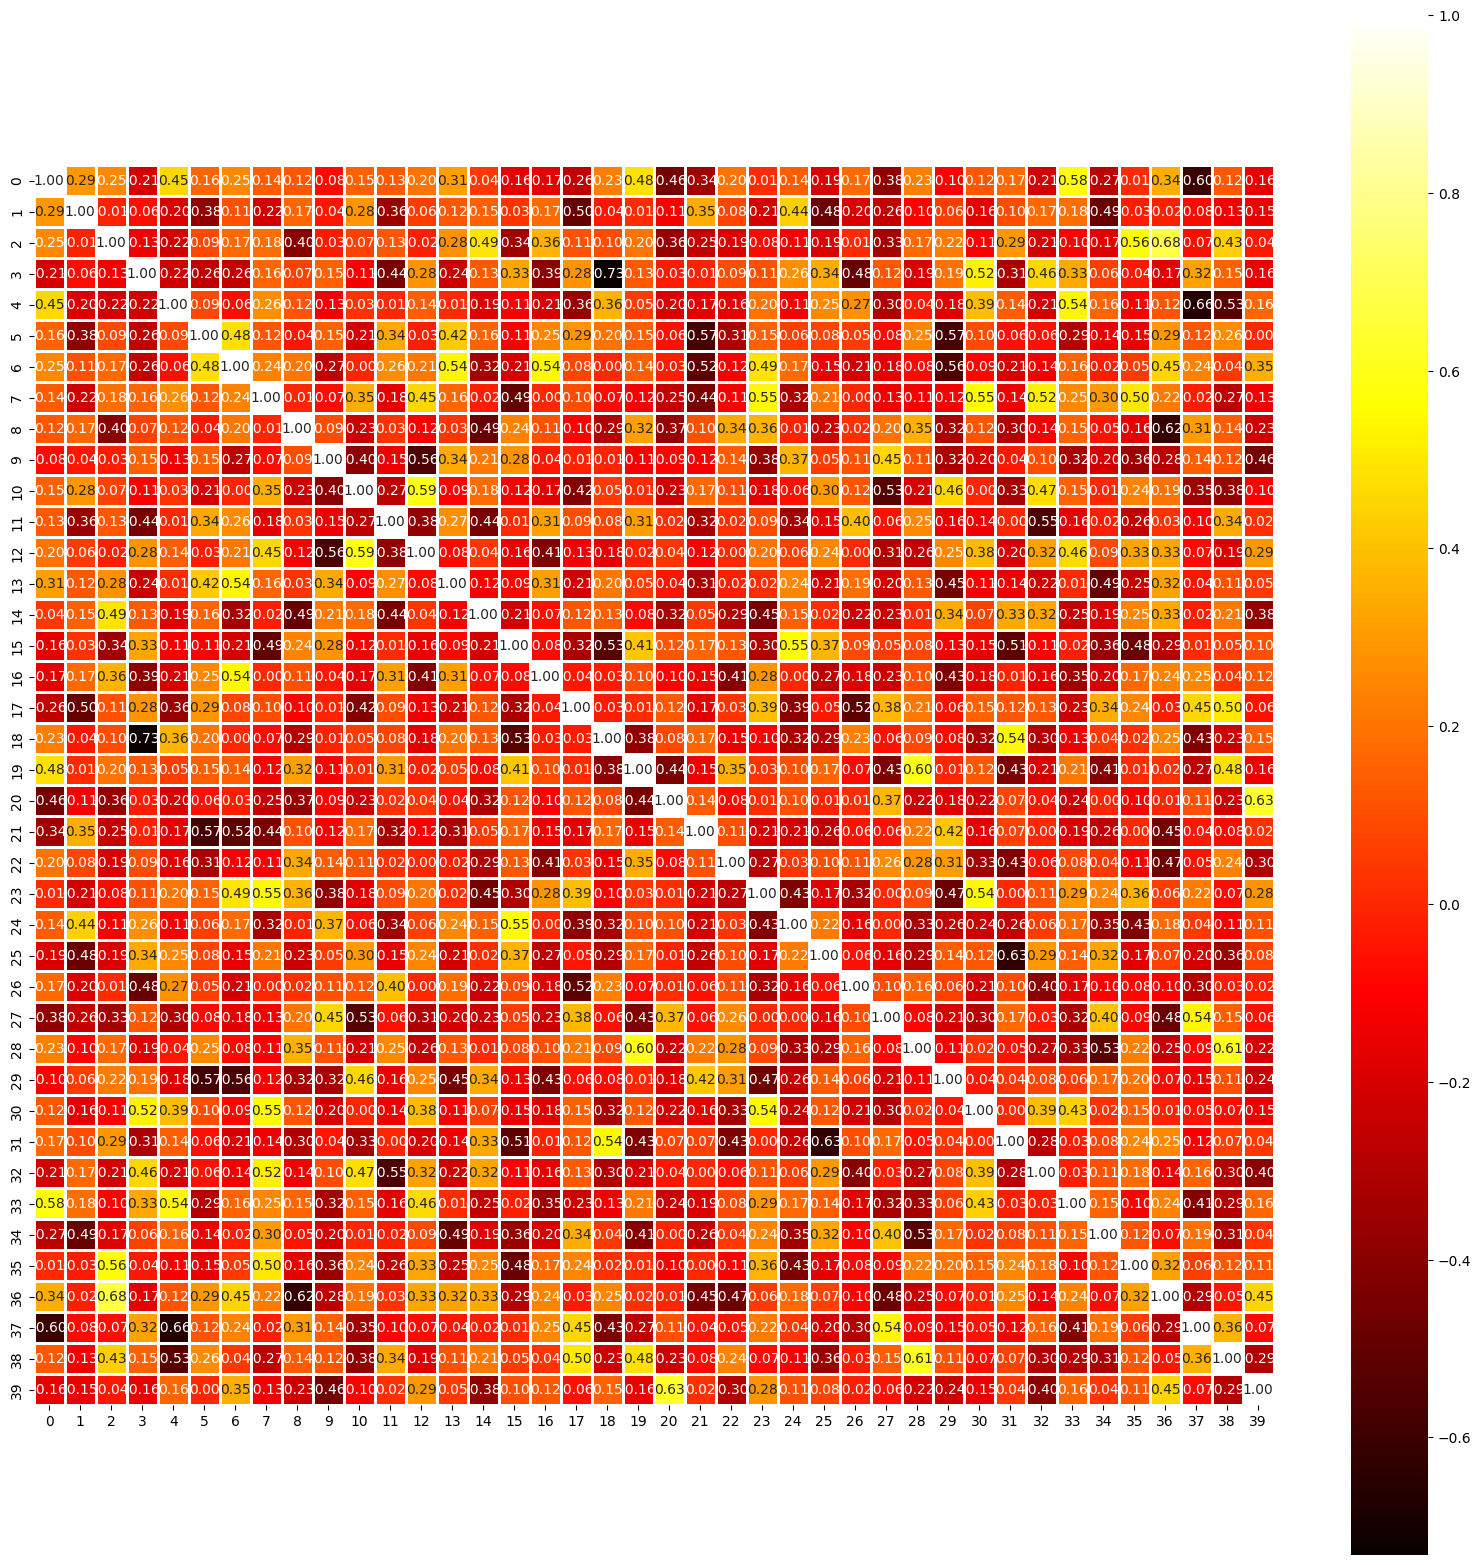

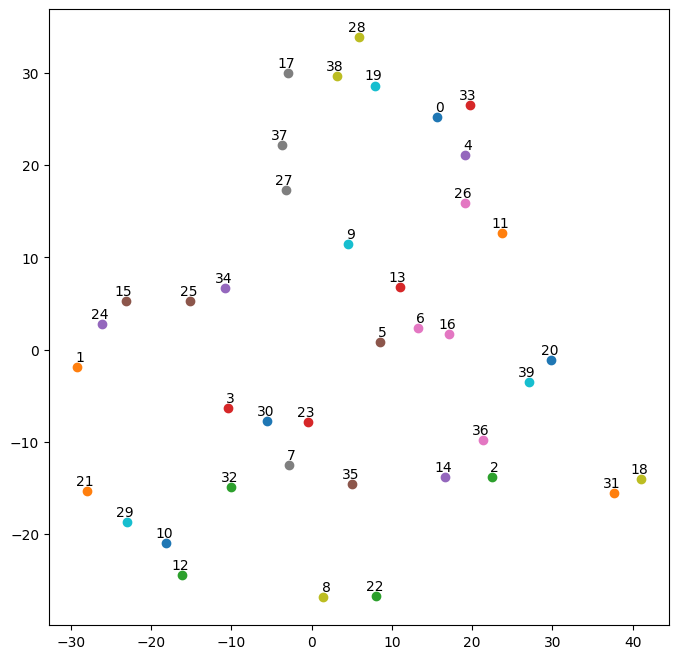

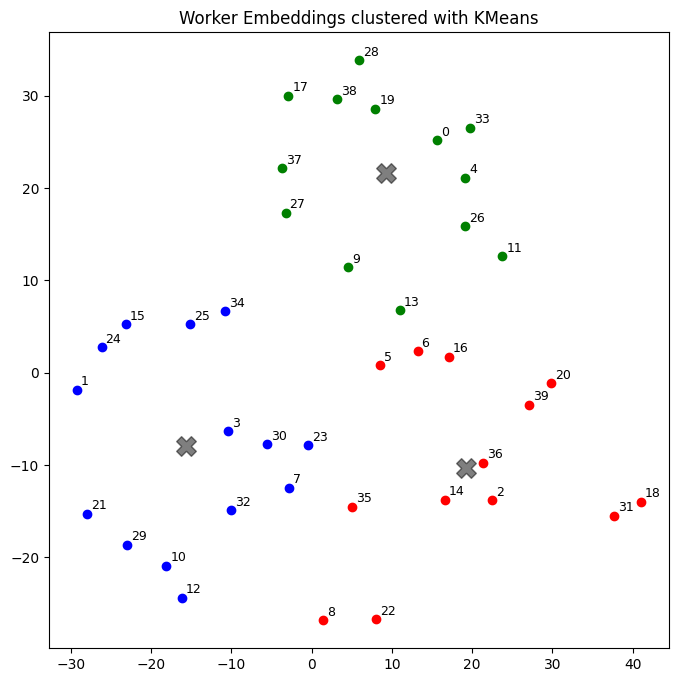

In [19]:
path = '/users/student/pg/pg24/abhishek/trlx/rm_checkpoint/checkpoint-39000/pytorch_model.bin'
s = Similarity(path, 5, 2)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()
cluster_and_plot(reduced_embeds, worker_ids, n_clusters=3)

/users/student/pg/pg24/abhishek/.conda/envs/rew/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


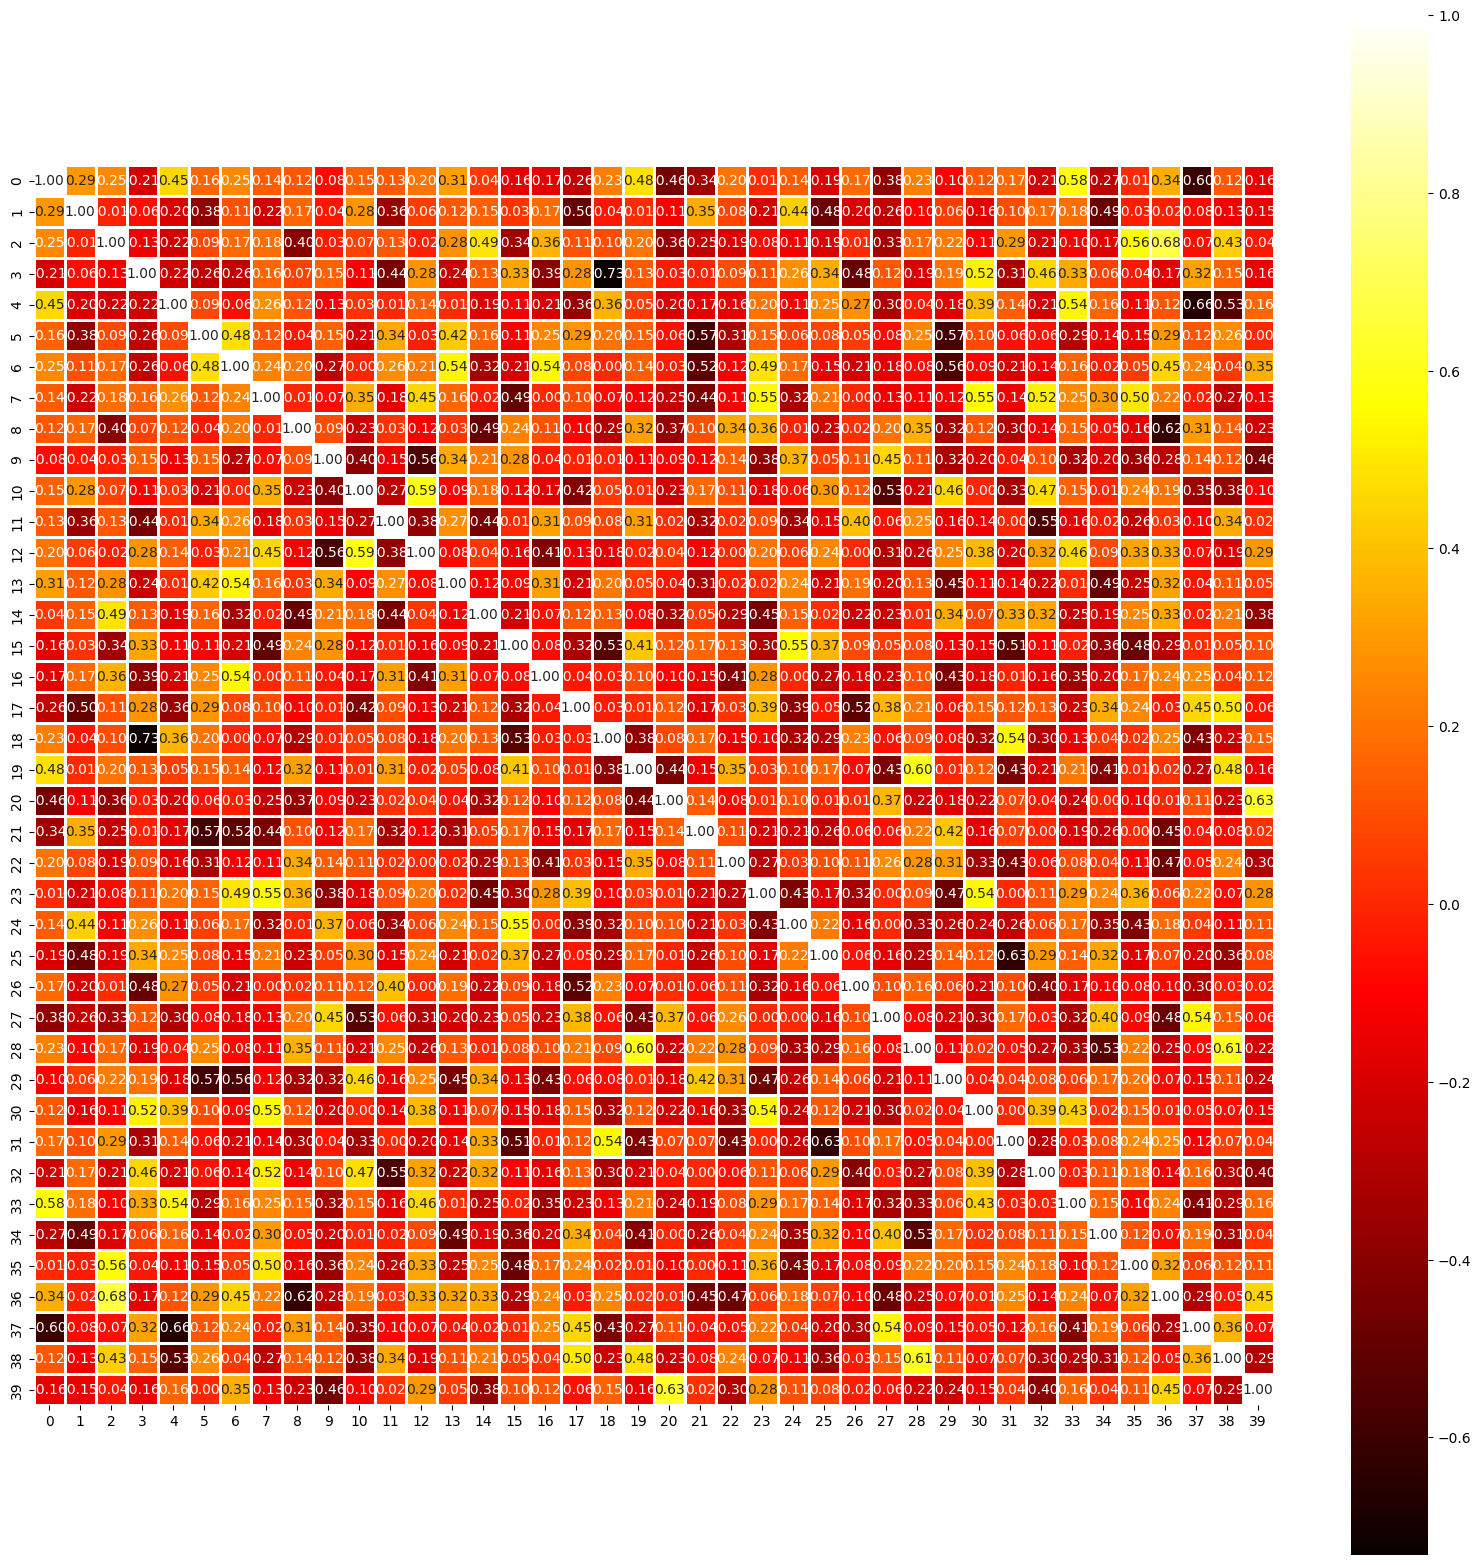

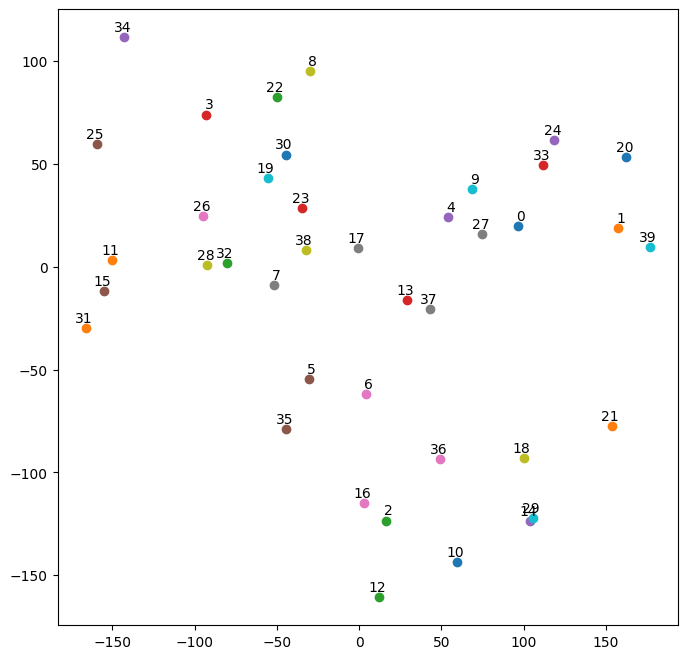

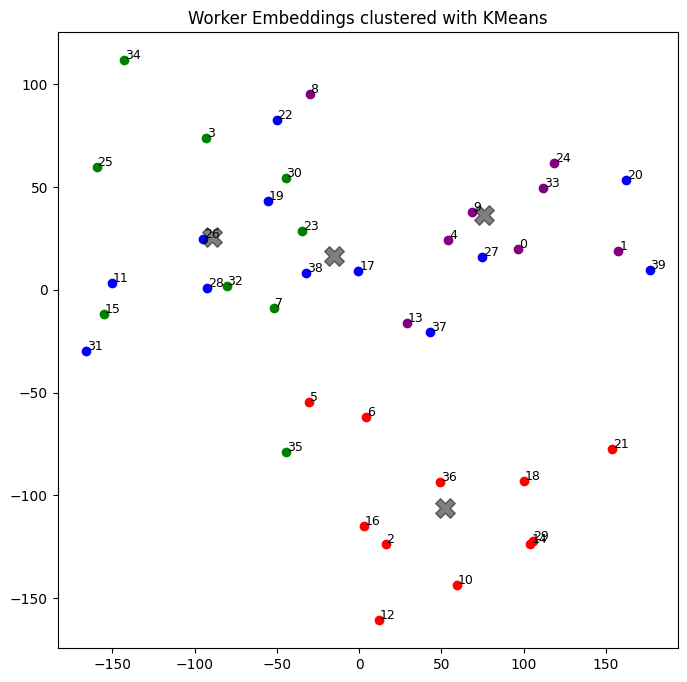

In [22]:
path = '/users/student/pg/pg24/abhishek/trlx/rm_checkpoint/checkpoint-39000/pytorch_model.bin'
s = Similarity(path, 5, 3)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()
cluster_and_plot(reduced_embeds, worker_ids, n_clusters=4)

- Epoch = 5
- Embed size = 32
- Workers = 21
- no of clusters =3,4

/users/student/pg/pg24/abhishek/.conda/envs/rew/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


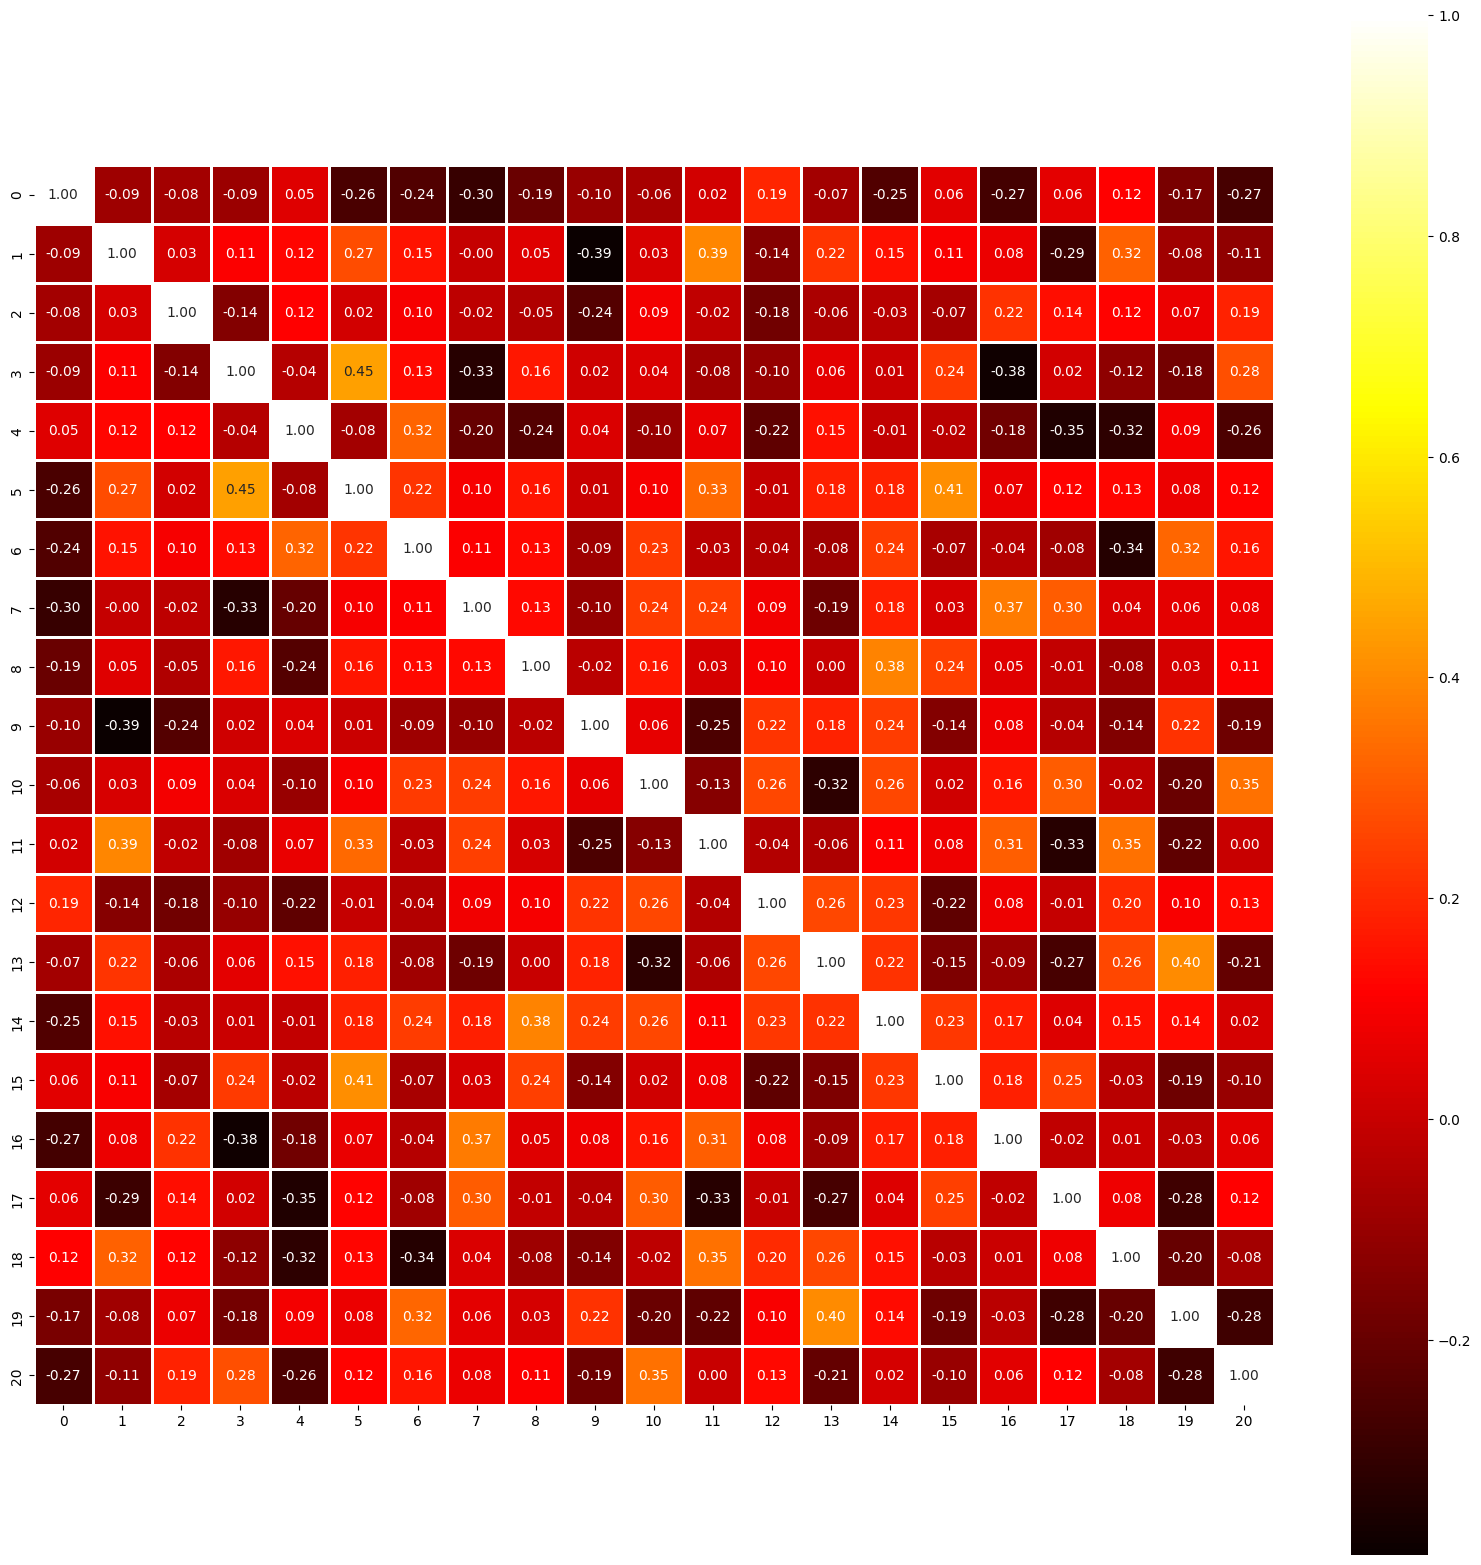

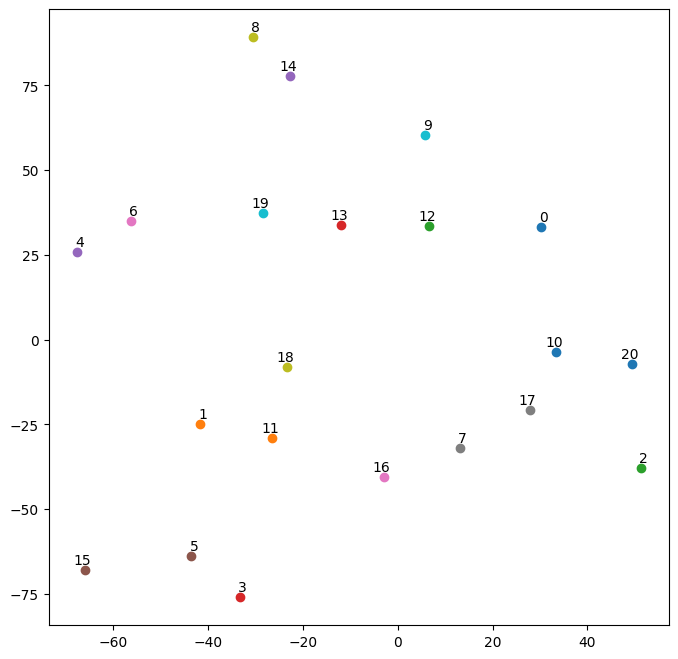

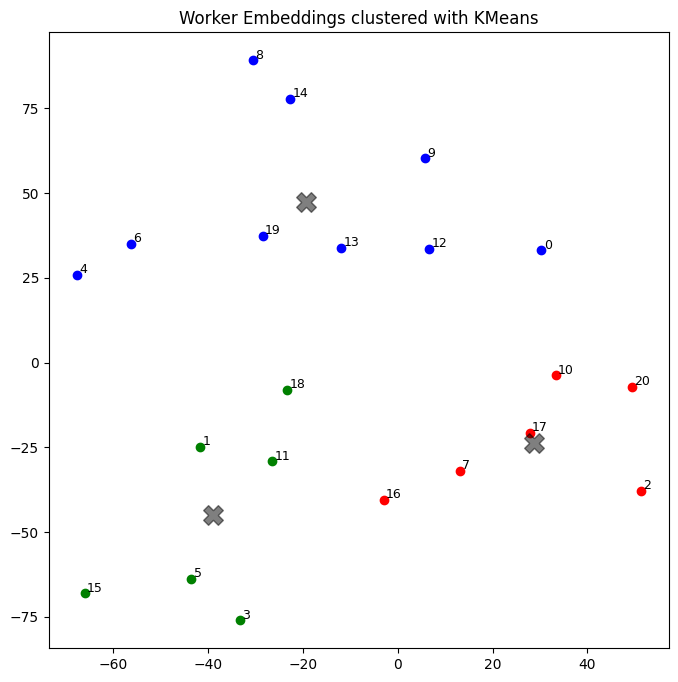

In [23]:
path = '/users/student/pg/pg24/abhishek/rm_checkpoint_multi/final_best_model_2/pytorch_model.bin'
s = Similarity(path, 5, 2)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()
cluster_and_plot(reduced_embeds, worker_ids, n_clusters=3)

/users/student/pg/pg24/abhishek/.conda/envs/rew/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


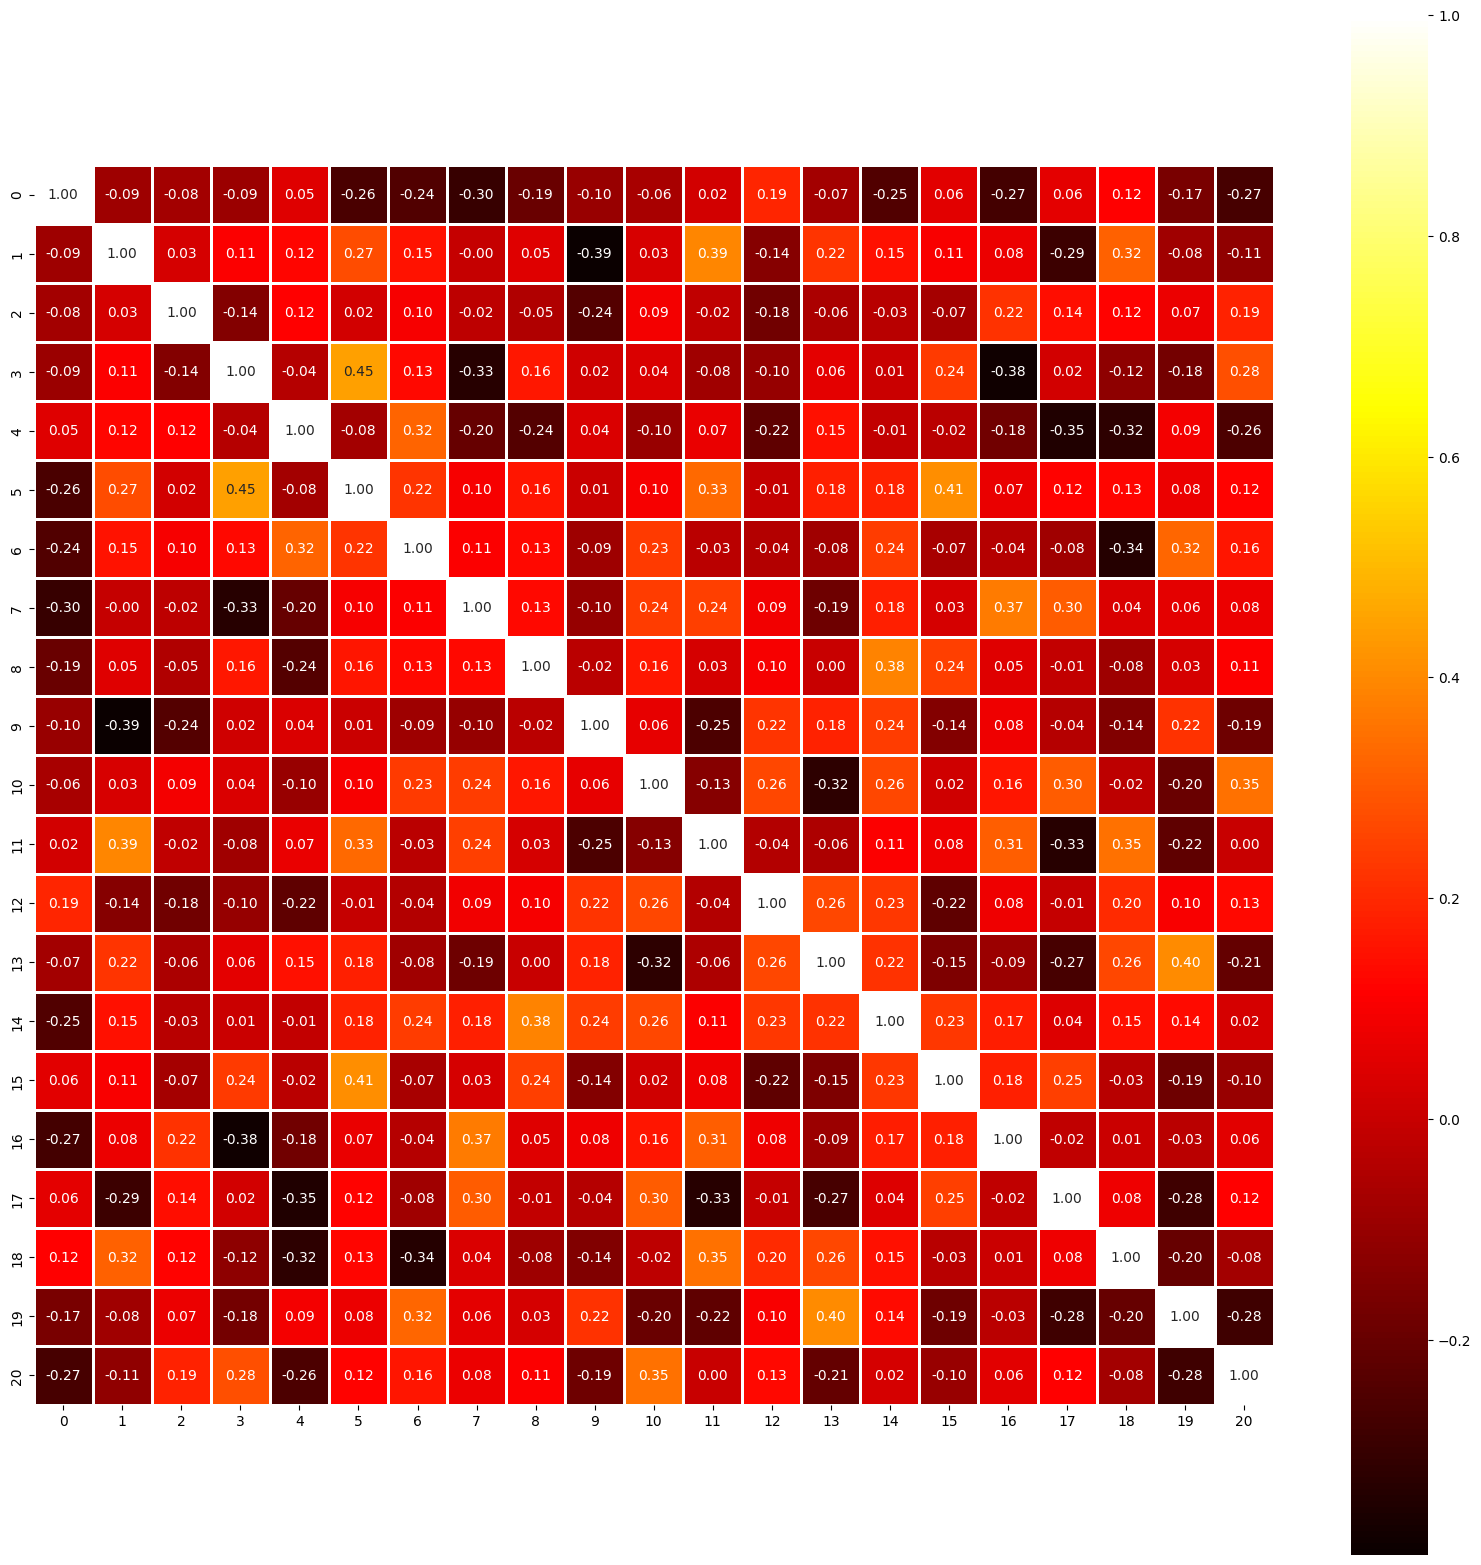

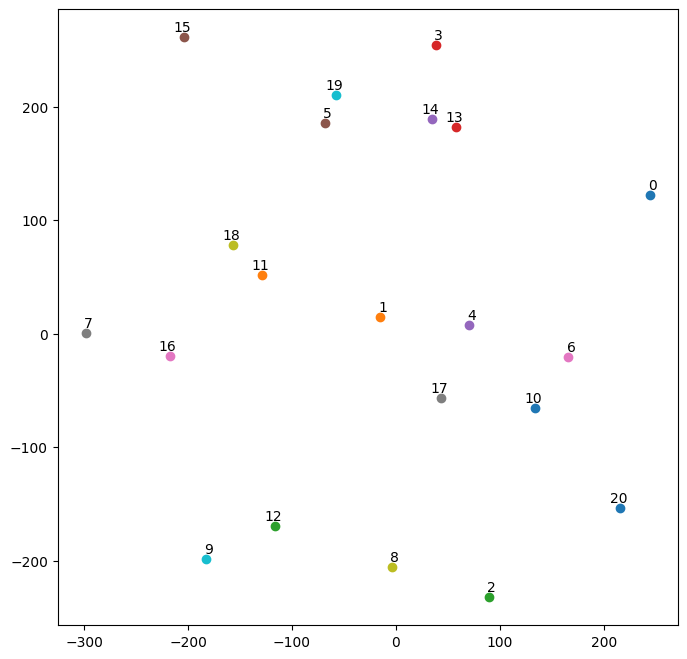

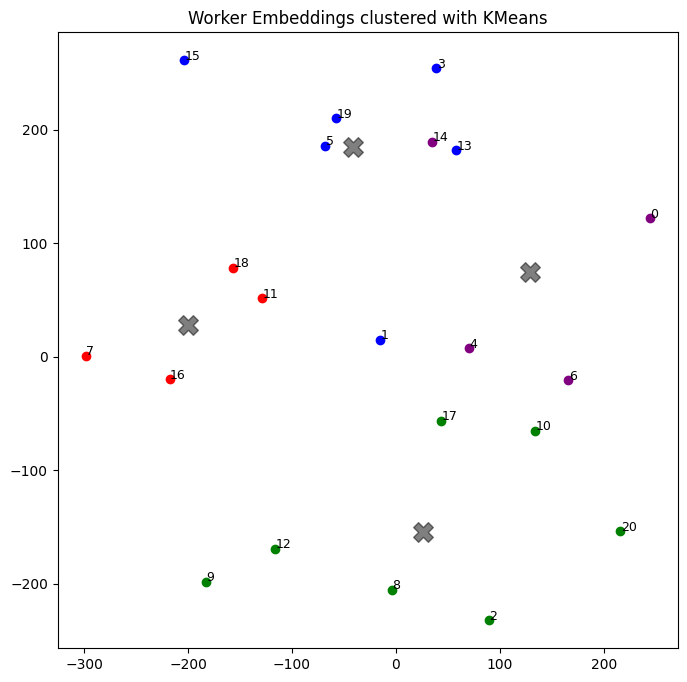

In [24]:
path = '/users/student/pg/pg24/abhishek/rm_checkpoint_multi/final_best_model_2/pytorch_model.bin'
s = Similarity(path, 5, 3)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()
cluster_and_plot(reduced_embeds, worker_ids, n_clusters=4)

- Epoch = 5
- Embed size = 8
- Workers = 21
- no of clusters =3,4

/users/student/pg/pg24/abhishek/.conda/envs/rew/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


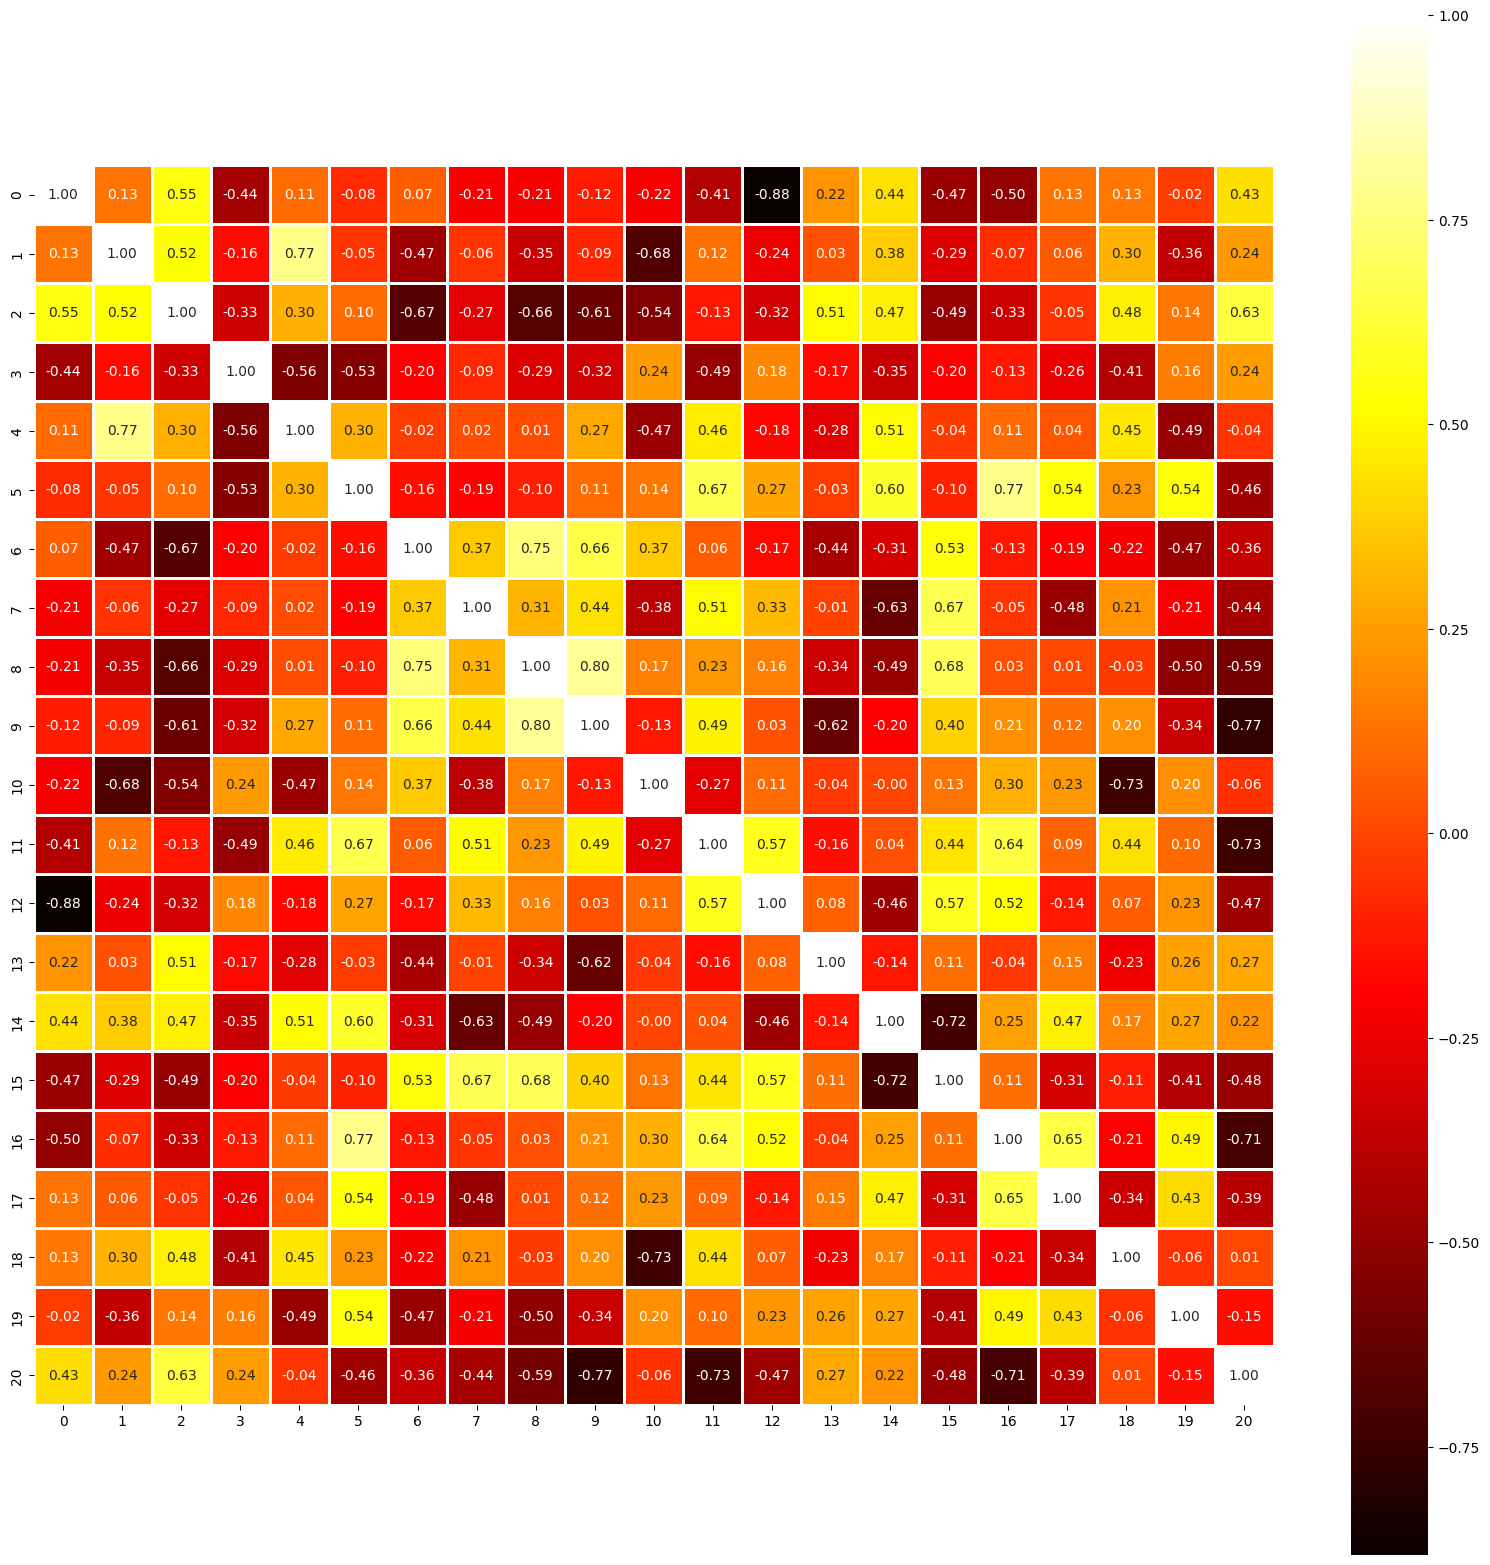

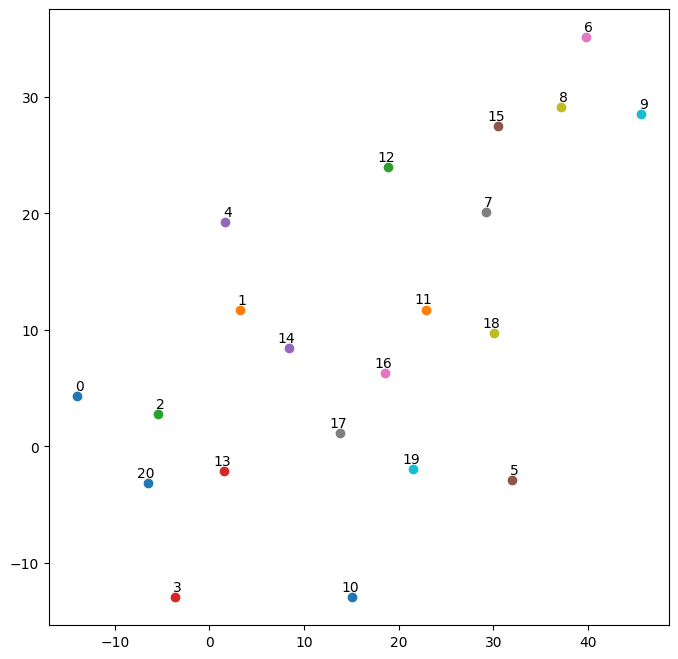

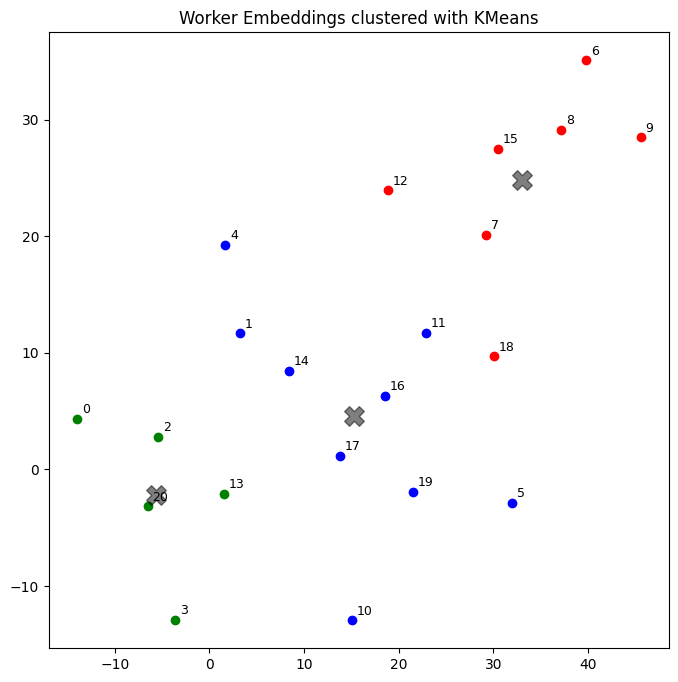

In [26]:
path = '/users/student/pg/pg24/abhishek/rm_checkpoint_multi/final_best_model/pytorch_model.bin'
s = Similarity(path, 5, 2)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()
cluster_and_plot(reduced_embeds, worker_ids, n_clusters=3)

/users/student/pg/pg24/abhishek/.conda/envs/rew/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


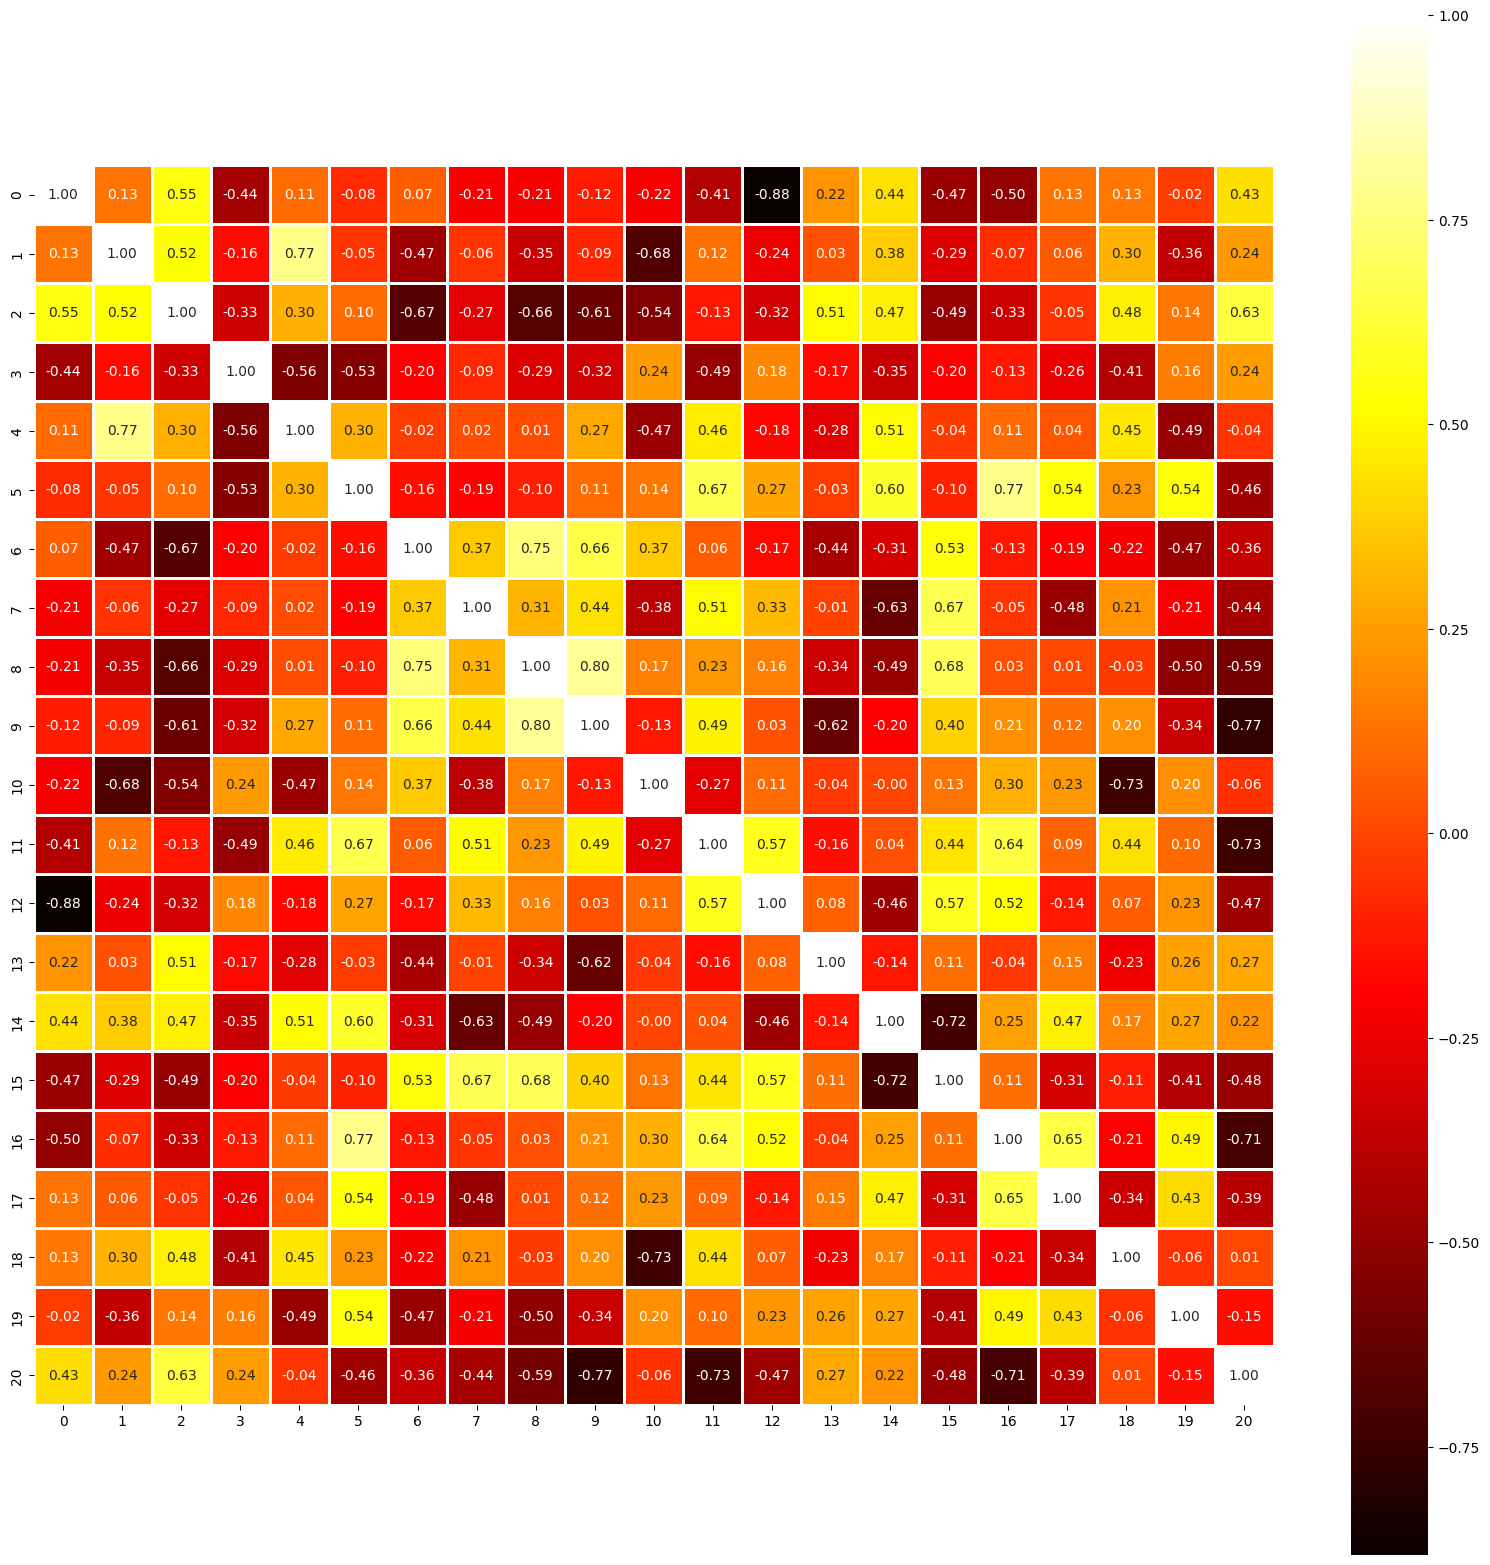

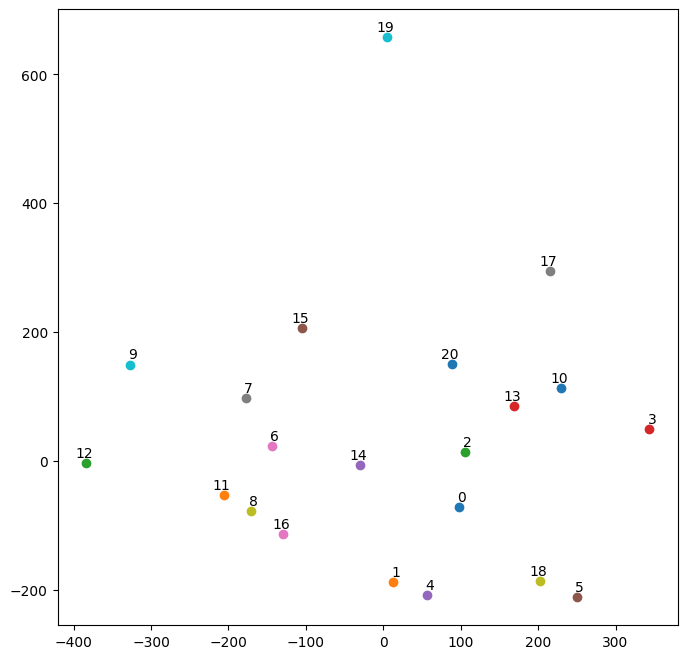

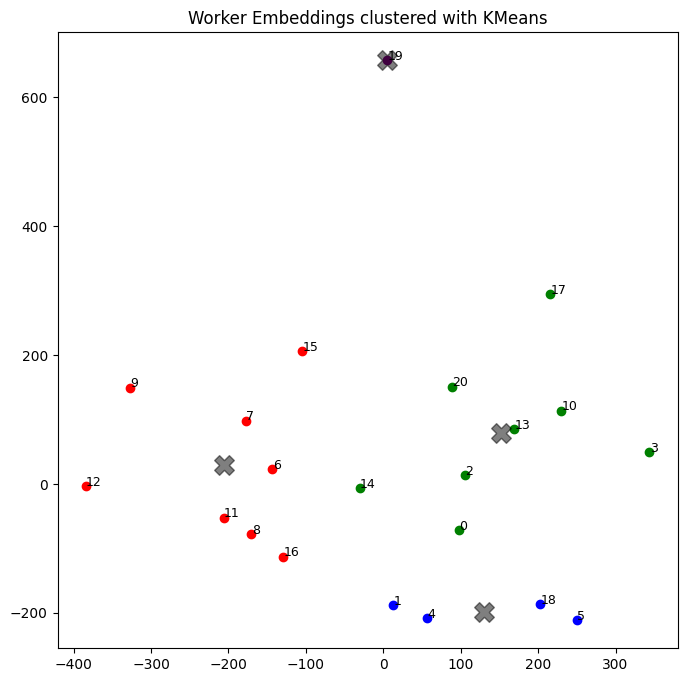

In [27]:
path = '/users/student/pg/pg24/abhishek/rm_checkpoint_multi/final_best_model/pytorch_model.bin'
s = Similarity(path, 5, 3)
similarity, reduced_embeds, worker_ids = s.main()

p = Plotting(similarity, reduced_embeds, worker_ids)
p.main()
cluster_and_plot(reduced_embeds, worker_ids, n_clusters=4)